# Notebook 7: repeated quote errors and strike coverage

This notebook compares 50 paired noise realisations per scenario, plus clean-input controls. The executed cell checks and reuses matching saved cases; missing cases are fitted. To recompute every fit, use `python run_repeated.py --fresh --workers 4` from the project folder. A full run can take several minutes. Run `build_milestone7_notebook.py` to update numerical text, tables and embedded figures together.


In [1]:
from run_repeated import main
from build_repeated_report import main as build_report
result = main(resume=True, workers=4)
build_report()


Fixed study: 808 fits; 808 matching saved cases, 0 to run.
Accepted 808/808; minimum calendar gap -9.995e-10.


# Repeated quote errors and the information contained in strike coverage
## Milestone 7: paired synthetic simulation and clean-input controls
Joel Cerraga | Quant research project | 21 September 2026

**Status:** synthetic method evaluation. This stage tests a fixed estimator across repeated quote perturbations and alternative strike patterns. It does not estimate a market-implied distribution, tune the smoothing penalty or construct confidence intervals for an observed market density.

### 1. Aim and experimental design

Milestone 6 showed that calendar-consistent fits could still misrepresent known tails. However, one noise realisation could not establish how much the estimated errors varied across repeated observations. This stage asks how performance changes with quote errors, the number of available strikes and their placement. It also asks which discrepancies remain when the input prices contain no random perturbation.

As Morris, White and Crowther explain in “Using simulation studies to evaluate statistical methods,” a simulation should distinguish its aims, data-generating mechanisms, targets, methods and performance measures [16, §3]. Here the targets are the known density and the probability and variance summaries in Equations (24)–(25). The method is the joint histogram estimator from Milestones 5–6, with 120 bins over $[0.3,2.2]$ in forward coordinates and smoothing coefficient $10^{-6}$ in Equation (12). Rates, dividend yield, forwards and the eight horizons are unchanged.

Both earlier benchmark families are retained: a single lognormal with 20% volatility, and a mixture with component weights 0.75/0.25 and volatilities 14%/40%. As Bahra discusses in his Bank of England paper, mixture distributions and their option prices can be assembled from weighted component distributions and values [1, §§3.5–3.6]. These known models generate and evaluate the synthetic observations; the fitting algorithm receives neither their component parameters nor their known probability weights.

The full design has two benchmark families, four quote patterns and two positive error limits, with 50 repetitions per scenario. Eight additional fits use clean input prices, once for each benchmark and quote pattern. There are therefore 800 noisy fits and eight clean controls, each fitting all eight horizons jointly. The repetition count was fixed after a feasibility and runtime pilot, before the full batch. It supports an exploratory comparison; the reported simulation uncertainty determines the precision of individual findings, rather than an assumption that 50 is universally sufficient.

### 2. Nested quotes and paired bounded errors

The original 81 strikes are preserved exactly. They are linearly spaced in strike between the previous endpoints; they are not equally spaced in log-moneyness. A master grid extends that spacing by 20 observations on each side, giving 121 strikes per horizon. The four quote patterns are the original 81; every second original strike, giving 41 across the same span; the central 41 original strikes; and all 121 extended strikes. Every supplied strike lies within the fixed density-fitting support.

Table 14. Quote patterns at 365 days. The same nested construction is used at every horizon. The fitting support remains [0.3, 2.2] in forward coordinates. Threshold entries indicate whether that strike is inside the quoted span.

| Pattern | Quotes per horizon | Minimum K/F | Maximum K/F | 0.8F inside? | 1.2F inside? | 1.8F inside? |
|---|---:|---:|---:|---|---|---|
| Original 81 | 81 | 0.6065 | 1.6487 | Yes | Yes | No |
| Sparse 41 | 41 | 0.6065 | 1.6487 | Yes | Yes | No |
| Central 41 | 41 | 0.8671 | 1.3882 | No | Yes | No |
| Extended 121 | 121 | 0.3460 | 1.9093 | Yes | Yes | Yes |



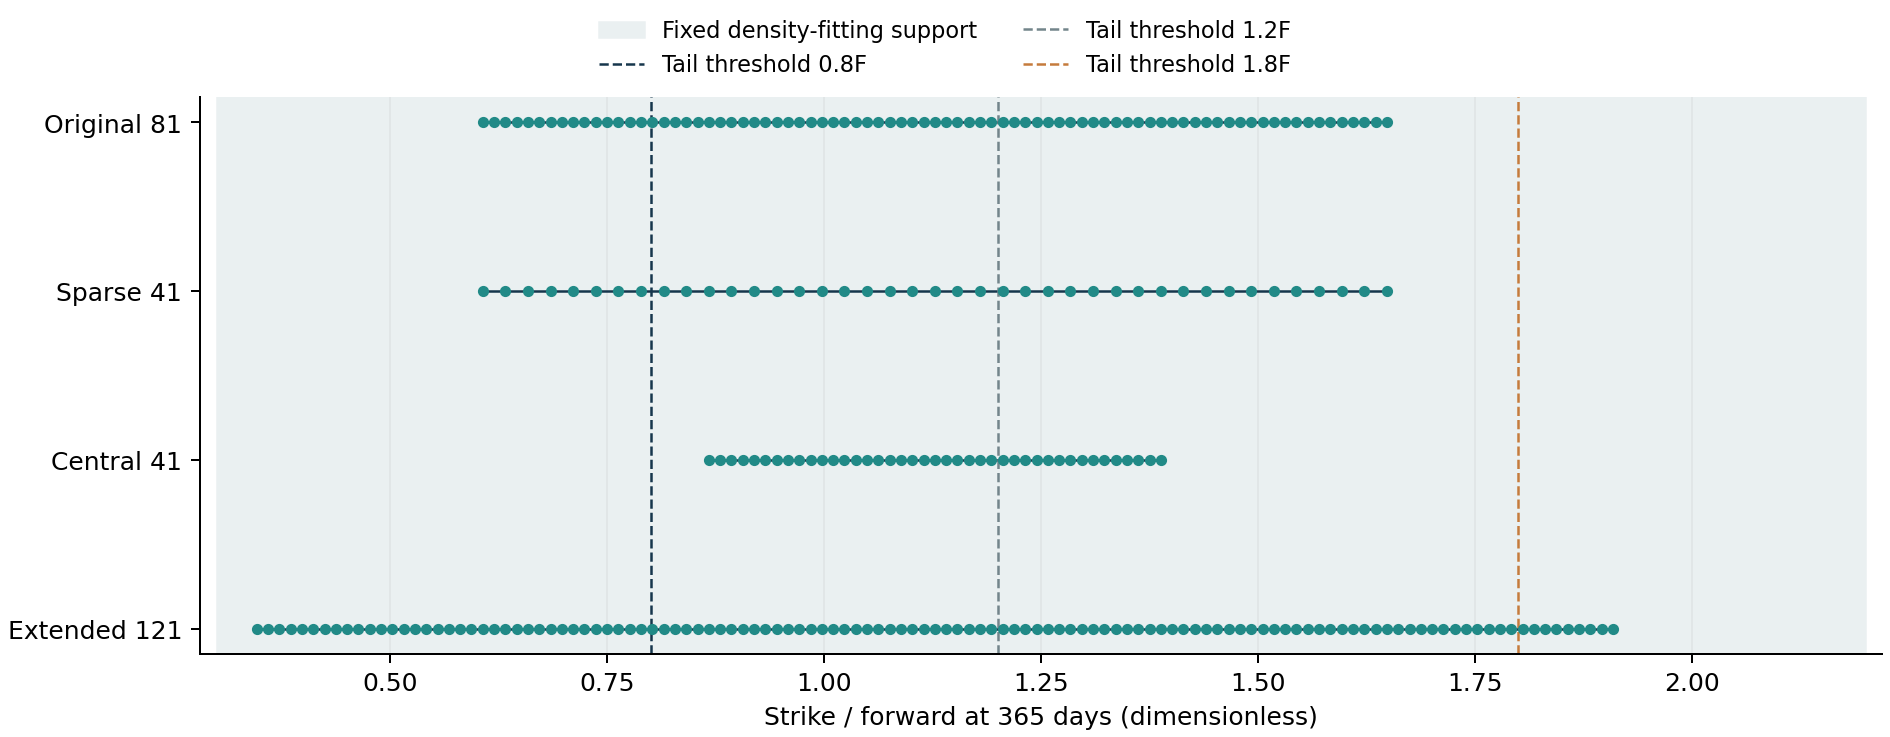




Figure 18. The four quote patterns at 365 days, expressed as strike divided by forward. Points identify actual supplied strikes. The shaded interval is the common density-fitting support, and dashed lines identify the three probability thresholds. The corresponding strike ranges change with horizon; the plotting example does not imply that 1.8F is quoted at every maturity.

The original-versus-sparse comparison reduces the number of observations without changing the endpoints. Central 41 versus Sparse 41 holds the count fixed while changing their locations and span. Extended 121 versus Original 81 changes both the span and the number of quotes; its effect cannot be attributed exclusively to either factor. The average squared price-loss convention in Equation (12) and the density penalty are retained throughout. The experiment does not retune regularisation for each coverage pattern.

Extending the strike range introduces small option values. A fixed additive error of 0.5 points could make some such prices negative. Instead of clipping simulated observations after generation, a symmetric bounded model is declared. For repetition $\nu$, horizon $m$, master-strike index $i$ and amplitude limit $a$, let:

$$y_{\nu mi}(a)=C_{mi}+\eta_{mi}(a)U_{\nu mi},\qquad \eta_{mi}(a)=\min\{a,C_{mi}/2\},\qquad U_{\nu mi}\sim\mathcal U[-1,1].\tag{26}$$

Here $C_{mi}$ is the clean benchmark call price and $a$ is either 0.1 or 0.5 index points. Conditional on that price, the error has zero mean and standard deviation $\eta_{mi}(a)/\sqrt{3}$; the generated price is at least $C_{mi}/2$. Thus $a$ is an error half-width limit, not a standard deviation. The exported diagnostics report the effective noise scale and how many selected quotes activate the bound.

This bound is an idealised data-generation assumption based on known synthetic prices. It is not estimated from observed bid–ask spreads or justified as a market microstructure model. The fitting objective does not use the known error variance to reweight observations. The perturbed prices may still violate monotonicity, convexity or calendar restrictions. Milestone 6 used an uncapped uniform perturbation, so these repeated results describe the newly declared model rather than an exact repetition-average of that earlier experiment.

Each repetition uses a reproducible PCG64 child stream generated through NumPy's `SeedSequence`. Its entire array of master-grid draws is shared across quote patterns, benchmark families and amplitude limits. A common strike therefore receives exactly the same perturbation across quote patterns for a fixed benchmark and amplitude. Across families the underlying uniform draw is shared, while the price-dependent bound may differ. Across amplitudes the same draw is rescaled. The saved initial and final generator states and full input-price export allow the construction to be checked independently of process scheduling.

### 3. Evaluation grids and the meaning of repeated error

All patterns are evaluated at the same 120 arithmetic midpoints between adjacent master strikes, at each of eight horizons. These 960 clean prices are withheld from every fit, including the extended pattern. A narrow-range fit is therefore not evaluated only where it was supplied observations. Separate exports distinguish evaluation within its quoted span, outside that span and within the original strike range. Empty outside-span sets for the extended pattern are recorded as unavailable, not as zero error.

Within each repetition, the principal price summary is RMSE across the 960 validation prices. The density summary averages full-domain $L_1$ error across the eight horizons, using Equation (23), including known probability outside the fitting support. The reported Monte Carlo means then average these repetition-level summaries. In particular, the average of repetition-level price RMSEs is not described as the square root of a single pooled error over every repetition.

The tail-probability study has a known value $\theta$ and one fitted estimate $\widehat\theta_\nu$ per repetition. Define $n_{\mathrm{sim}}=50$. The following quantities distinguish average error from variation between fits:

$$\begin{aligned}
\overline\theta&=\frac{1}{n_{\mathrm{sim}}}\sum_{\nu=1}^{n_{\mathrm{sim}}}\widehat\theta_\nu,
&\widehat{\operatorname{Bias}}&=\overline\theta-\theta,\\
s_\theta^2&=\frac{1}{n_{\mathrm{sim}}-1}\sum_{\nu=1}^{n_{\mathrm{sim}}}(\widehat\theta_\nu-\overline\theta)^2,\\
\operatorname{RMSE}_\theta^2&=\frac{1}{n_{\mathrm{sim}}}\sum_{\nu=1}^{n_{\mathrm{sim}}}(\widehat\theta_\nu-\theta)^2
=\widehat{\operatorname{Bias}}^2+\frac{n_{\mathrm{sim}}-1}{n_{\mathrm{sim}}}s_\theta^2.
\end{aligned}\tag{27}$$

The last equality is a finite-sample algebraic identity; the factor $(n_{\mathrm{sim}}-1)/n_{\mathrm{sim}}$ is required because $s_\theta^2$ uses the sample-variance denominator. The empirical SD measures variation across simulated fits. A small SD can coexist with a substantial bias against the known answer.

As Morris and co-authors distinguish in their discussion of simulation uncertainty, the precision of an estimated performance measure is a separate quantity [16, §5.2]. For a repetition-level scalar $z_\nu$, with sample SD $s_z$, the Monte Carlo standard error of its reported mean is:

$$\operatorname{MCSE}(\overline z)=\frac{s_z}{\sqrt{n_{\mathrm{sim}}}}.\tag{28}$$

Equation (28) also applies to the estimated tail bias because the known probability is a constant. It quantifies the uncertainty associated with a finite number of simulated repetitions under this declared experiment. It is not an error bar for an individual fitted market probability and does not measure uncertainty in the assumed benchmark, forward or quote-error model.

For a comparison of quote patterns $A$ and $B$, pairing is preserved when calculating the uncertainty of their difference. With $\Delta_\nu=z_\nu^{(A)}-z_\nu^{(B)}$, the reported contrast is:

$$\overline\Delta=\frac{1}{n_{\mathrm{sim}}}\sum_{\nu=1}^{n_{\mathrm{sim}}}\Delta_\nu,\qquad
\operatorname{MCSE}(\overline\Delta)=\sqrt{\frac{\sum_{\nu=1}^{n_{\mathrm{sim}}}(\Delta_\nu-\overline\Delta)^2}{n_{\mathrm{sim}}(n_{\mathrm{sim}}-1)}}.\tag{29}$$

Morris and co-authors discuss matching repetitions across simulation conditions [16, §5.4]. Here Equation (29) applies the ordinary mean-SE formula to those observed differences, retaining their within-repetition dependence. Positive or negative covariance is not replaced by an assumption of independence. The tail contrast uses absolute probability error for each repetition, so a negative change has a direct interpretation as smaller mean absolute error.

### 4. Recovery under repeated errors and changed coverage

Table 15. Average recovery errors across 50 repetitions per scenario. Parentheses contain one Monte Carlo standard error of the mean. Each repetition aggregates eight horizons; the common validation grid contains 960 withheld clean prices. Density L1 is dimensionless and price RMSE is in index points.

| Benchmark | Error limit a (points) | Quote pattern | Mean density L1 (MCSE) | Mean price RMSE (MCSE) |
|---|---:|---|---:|---:|
| Single lognormal | 0.1 | Original 81 | 0.0307 (4.2e-05) | 0.1146 (0.0036) |
| Single lognormal | 0.1 | Sparse 41 | 0.0311 (4.6e-05) | 0.1238 (0.0041) |
| Single lognormal | 0.1 | Central 41 | 0.0364 (0.0001) | 1.0844 (0.0150) |
| Single lognormal | 0.1 | Extended 121 | 0.0298 (1e-05) | 0.0374 (0.0002) |
| Single lognormal | 0.5 | Original 81 | 0.0357 (0.0001) | 0.2251 (0.0072) |
| Single lognormal | 0.5 | Sparse 41 | 0.0386 (0.0002) | 0.2535 (0.0070) |
| Single lognormal | 0.5 | Central 41 | 0.0448 (0.0003) | 1.7134 (0.0626) |
| Single lognormal | 0.5 | Extended 121 | 0.0335 (0.0001) | 0.0931 (0.0008) |
| Two-lognormal mixture | 0.1 | Original 81 | 0.0470 (0.0001) | 0.4459 (0.0114) |
| Two-lognormal mixture | 0.1 | Sparse 41 | 0.0479 (0.0001) | 0.4962 (0.0144) |
| Two-lognormal mixture | 0.1 | Central 41 | 0.1134 (0.0001) | 7.8641 (0.0208) |
| Two-lognormal mixture | 0.1 | Extended 121 | 0.0443 (0.0001) | 0.1254 (0.0002) |
| Two-lognormal mixture | 0.5 | Original 81 | 0.0575 (0.0003) | 0.9229 (0.0211) |
| Two-lognormal mixture | 0.5 | Sparse 41 | 0.0623 (0.0003) | 1.0044 (0.0206) |
| Two-lognormal mixture | 0.5 | Central 41 | 0.1223 (0.0005) | 8.3539 (0.0789) |
| Two-lognormal mixture | 0.5 | Extended 121 | 0.0521 (0.0001) | 0.1596 (0.0010) |



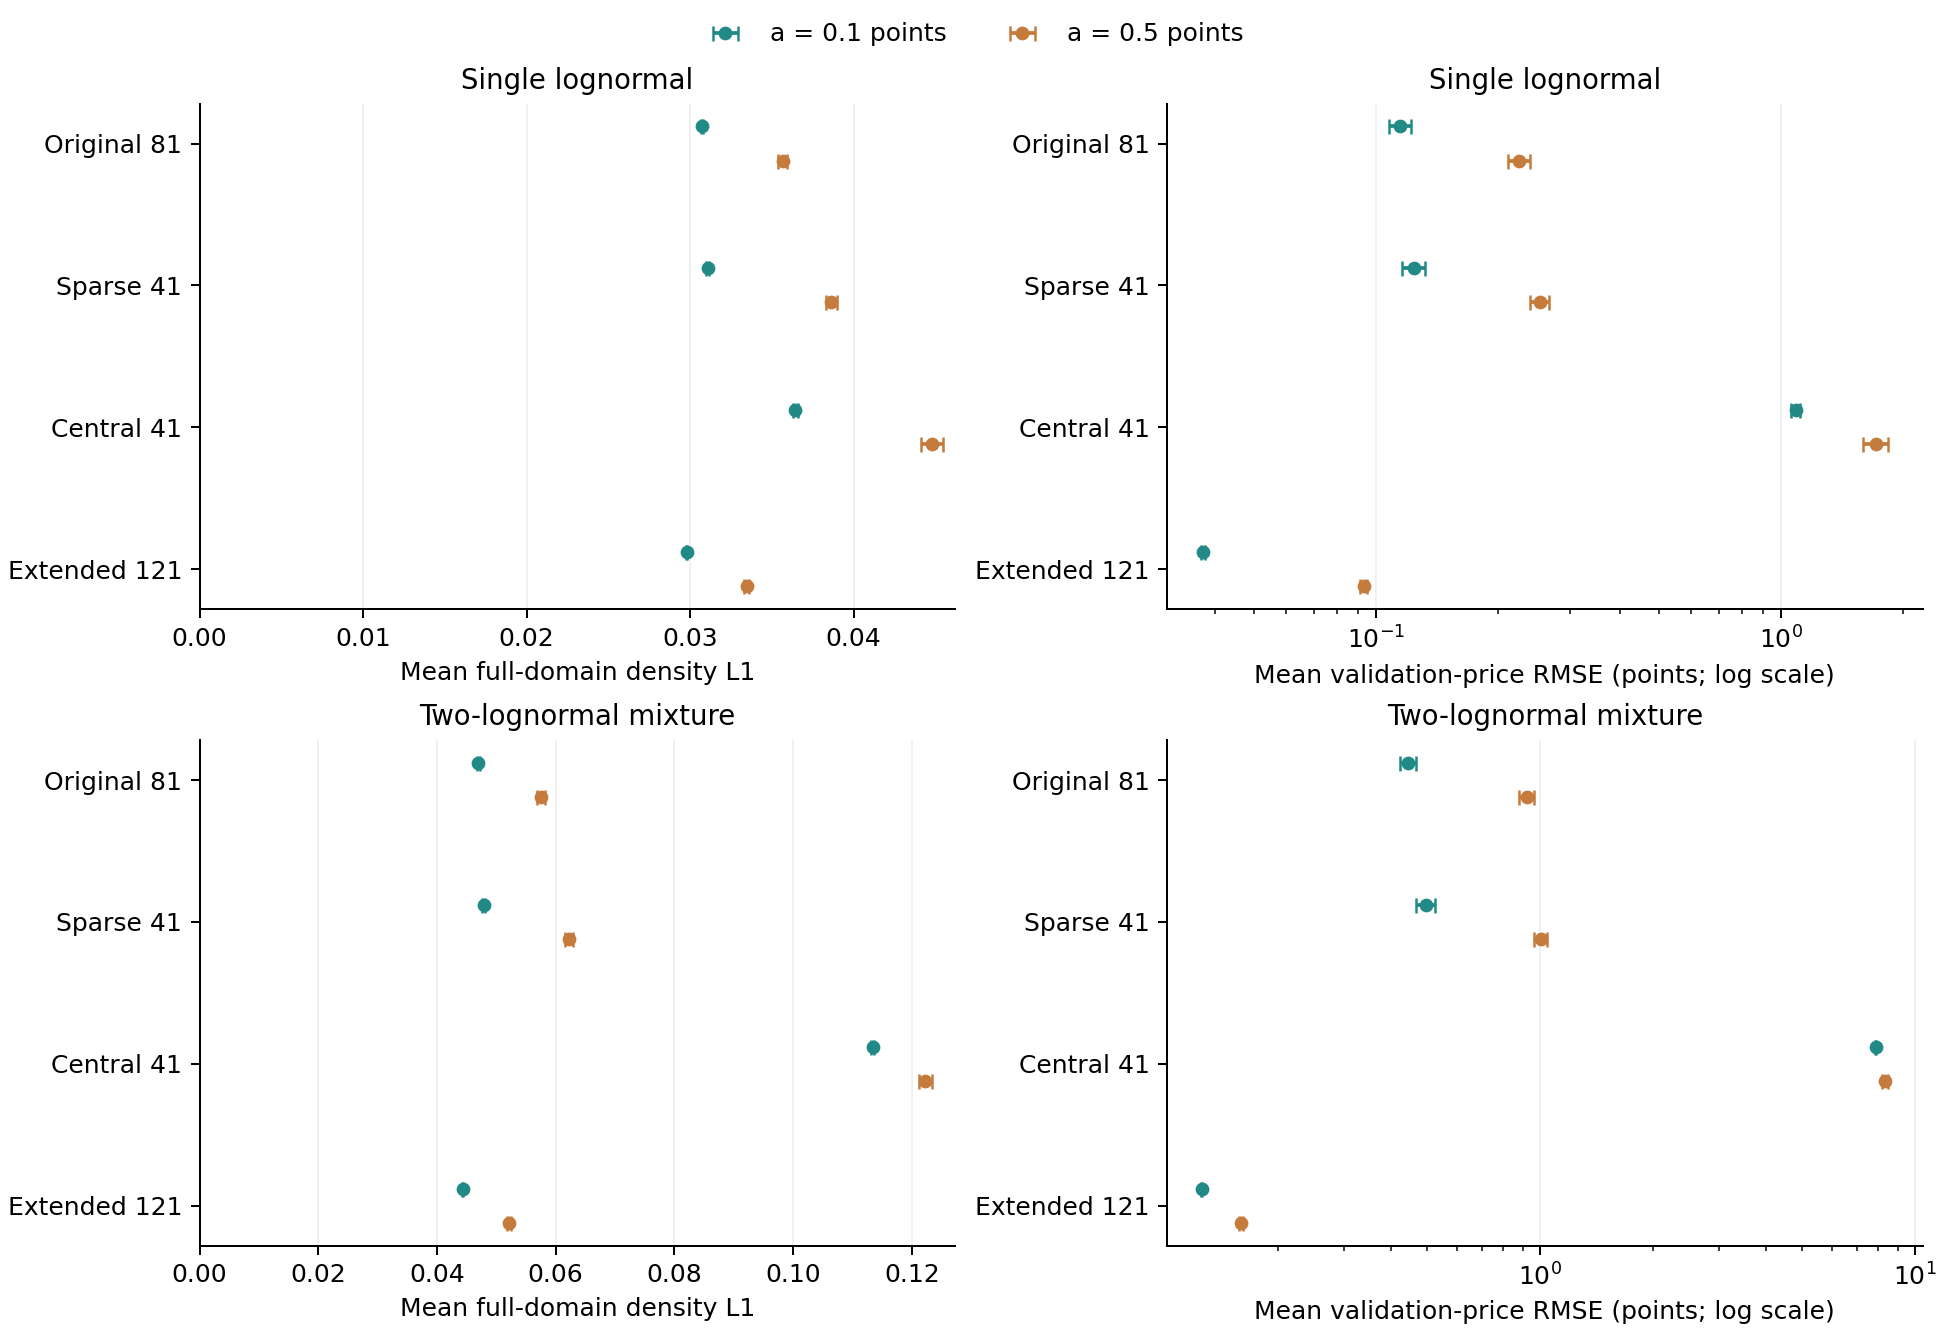




Figure 19. Mean full-domain density error and mean validation-price RMSE across 50 repetitions per scenario. Bars show the mean plus or minus two Monte Carlo standard errors, describing the precision of the simulation mean. They are not the spread of individual estimates or confidence intervals for a density. Price panels use logarithmic horizontal scales; density panels use linear scales.

For the single lognormal benchmark at $a=0.5$, Central 41 minus Sparse 41 gives a mean density-error change of +0.00614, with MCSE 0.00038. Both patterns contain 41 quotes per horizon. Their difference tests quote placement and range at a fixed count; it is not explained by deleting more observations from one than the other.

For the two-lognormal mixture benchmark at $a=0.5$, Central 41 minus Sparse 41 gives a mean density-error change of +0.06001, with MCSE 0.00064. Both patterns contain 41 quotes per horizon. Their difference tests quote placement and range at a fixed count; it is not explained by deleting more observations from one than the other.

With clean mixture prices, the Central 41 control has RMSE 0.1186 within its quoted span but 7.7981 over the common validation grid. This discrepancy exists without random quote perturbations. The clean control still has finite-support, histogram and regularisation approximation errors; it is not an exact population-bias calculation.

The experiment changes what prices are supplied while keeping the estimator fixed. Consequently, differences combine the information in those observations with the behaviour of this specific regularised histogram model. They do not demonstrate that every estimator responds identically or that wider coverage guarantees accurate recovery outside the quoted range.

### 5. Separating tail bias, dispersion and clean-input error

Table 16. Error in the 365-day probability above 1.8F with a = 0.5 points. The known probabilities are 0.1187% (single lognormal) and 1.1885% (mixture). All errors and SDs are percentage points. The clean column uses exact input prices once, without a Monte Carlo error bar.

| Benchmark | Pattern | Clean-input error | Mean error (MCSE) | Empirical SD | Root MSE |
|---|---|---:|---:|---:|---:|
| Single lognormal | Original 81 | +0.0044 | -0.0443 (0.0047) | 0.0332 | 0.0552 |
| Single lognormal | Sparse 41 | +0.0044 | -0.0438 (0.0058) | 0.0408 | 0.0595 |
| Single lognormal | Central 41 | -0.0130 | +0.0688 (0.0175) | 0.1238 | 0.1405 |
| Single lognormal | Extended 121 | +4.69e-05 | -0.0026 (0.0041) | 0.0289 | 0.0287 |
| Two-lognormal mixture | Original 81 | +0.2265 | +0.3108 (0.0330) | 0.2333 | 0.3873 |
| Two-lognormal mixture | Sparse 41 | +0.2241 | +0.3159 (0.0306) | 0.2164 | 0.3817 |
| Two-lognormal mixture | Central 41 | +0.4398 | +0.1061 (0.0537) | 0.3794 | 0.3903 |
| Two-lognormal mixture | Extended 121 | -0.0503 | -0.0436 (0.0043) | 0.0304 | 0.0530 |



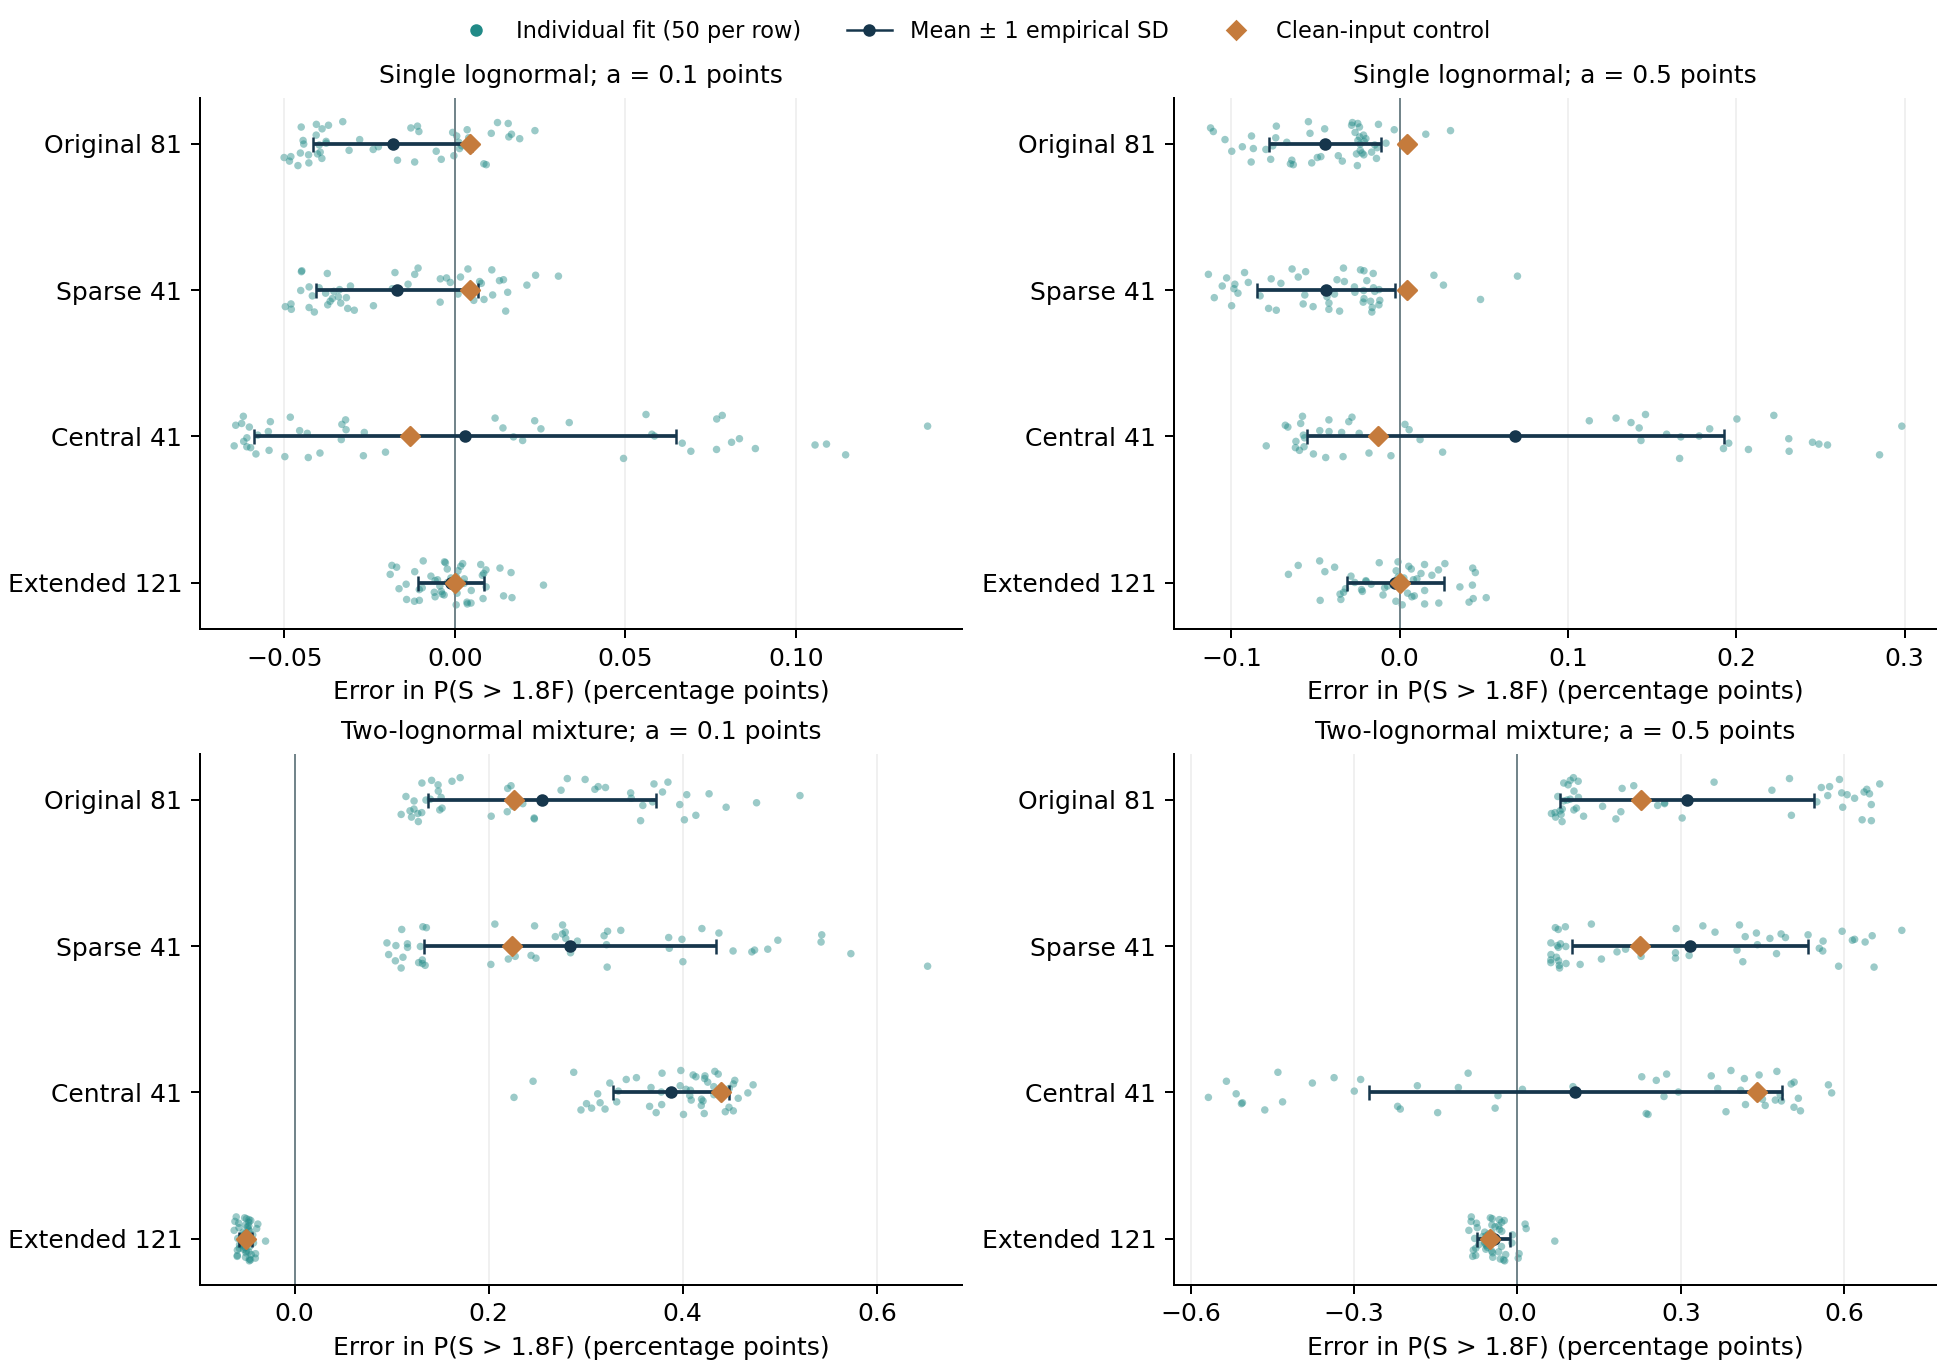




Figure 20. Errors in the 365-day risk-neutral probability above 1.8F, in percentage points. Each row displays all 50 noisy fits, their mean plus or minus one empirical SD, and the corresponding clean-input control. Vertical offsets separate points for visibility and carry no numerical meaning. The spread shown here differs from the Monte Carlo mean-error bars in Figure 19. Horizontal scales may differ between panels.

As Malz explains in his New York Fed research paper, the position of a probability threshold relative to available option strikes determines the reliance on extrapolation [14, §§2.3, 3.2]. At 365 days, $1.8F$ is beyond the original, sparse and central quote spans but lies inside the extended span. It remains inside the fixed density support for every case. These are three different boundaries: a quoted range, a fitting domain and a probability threshold.

For the single lognormal benchmark at $a=0.5$, the original pattern gives an average probability of 0.0744% above $1.8F$, compared with the known 0.1187%. The extended pattern gives 0.1161%. Its paired change in mean absolute error is -0.0231 percentage points (MCSE 0.0050).

For the two-lognormal mixture benchmark at $a=0.5$, the original pattern gives an average probability of 1.4994% above $1.8F$, compared with the known 1.1885%. The extended pattern gives 1.1450%. Its paired change in mean absolute error is -0.2632 percentage points (MCSE 0.0338).

Table 17. Paired changes at a = 0.5 points, with one MCSE in parentheses. Each difference uses matched repetitions. Negative values mean a smaller error for the first pattern. The tail measure is mean absolute probability error at 365 days, in percentage points.

| Benchmark | First pattern − second pattern | Change in density L1 | Change in mean absolute tail error (pp) |
|---|---|---:|---:|
| Single lognormal | Sparse 41 − Original 81 | +0.0030 (0.0001) | +0.0042 (0.0030) |
| Single lognormal | Central 41 − Original 81 | +0.0091 (0.0004) | +0.0661 (0.0129) |
| Single lognormal | Extended 121 − Original 81 | -0.0022 (0.0001) | -0.0231 (0.0050) |
| Single lognormal | Central 41 − Sparse 41 | +0.0061 (0.0004) | +0.0618 (0.0132) |
| Two-lognormal mixture | Sparse 41 − Original 81 | +0.0048 (0.0003) | +0.0050 (0.0196) |
| Two-lognormal mixture | Central 41 − Original 81 | +0.0648 (0.0007) | +0.0475 (0.0425) |
| Two-lognormal mixture | Extended 121 − Original 81 | -0.0053 (0.0004) | -0.2632 (0.0338) |
| Two-lognormal mixture | Central 41 − Sparse 41 | +0.0600 (0.0006) | +0.0425 (0.0394) |

The clean-input controls help locate error that does not require random perturbations. They retain discretisation, regularisation, finite support and the limited set of supplied option values. Their error therefore cannot be assigned to one of these features alone. They also do not estimate the bias under random errors: the mean of a constrained estimator need not equal its value at the mean input.

The complete exports retain all three tail probabilities and the normalised terminal-level variance at every horizon. The paper focuses its repeated-tail comparison on the previously problematic upper event. All probabilities remain risk-neutral, and all thresholds remain relative to the forward. No historical prediction or physical event frequency is inferred.

### 6. Numerical checks and reproducibility

All 808 of 808 planned fits were accepted, covering 6,464 marginal distributions. There were 0 failed fits. The worst final calendar gap was -9.995e-10, inside the $10^{-8}$ acceptance tolerance. The maximum mass and normalised-mean residuals across solver rounds were 4.316e-12 and 6.652e-11; the minimum raw mass was -1.326e-12. Raw signed residuals are retained. No probabilities or quotes were clipped or renormalised.

The largest residual-variable equality mismatch was 3.640e-13. The most demanding solve used 40 interior-point iterations, and at most 7 calendar-refinement rounds were required. The maximum density-integration error estimate was 2.000e-07. These are numerical diagnostics, not exact arithmetic certificates.

Every fit uses Clarabel with the explicit-residual formulation described in Milestone 6. As Goulart and Chen describe in their solver paper, numerical feasibility and optimality are assessed through solver stopping conditions [15, §§1, 2.6]. This experiment additionally checks the returned marginal probabilities and the endpoint/interior calendar minima from Equations (18)–(19). The same tolerances and fixed penalty apply across all scenarios. The calendar claim covers the eight fitted horizons and all nonnegative strikes under the common-bin model, subject to floating-point tolerance; it does not validate an interpolation between horizons.

Each attempted case is saved separately with its specification, solver history, probability weights, risk summaries, code-and-protocol fingerprint and a content checksum. The runner can resume matching cases without changing the random draws. A different numerical source or protocol invalidates the cached case rather than silently mixing experiments. Statistical summaries require every planned repetition in the group to be accepted. As Morris and co-authors note when discussing nonconvergence, missing simulation estimates require examination [16, §5.1]; this pipeline records failures instead of silently treating a selected subset as the complete study.

Independent tests check the bounded-error mean and variance by integration, recover random draws from saved states, compare the statistical summaries with hand calculations, verify that no validation midpoint was supplied to a fit and reconstruct reported calendar and tail results from saved probabilities. Earlier notebooks and both offline interactive companions are checked against Milestone 6. Figure 4 retains the user's explanation placement.

### 7. Limits and continuation

The experiment conditions on known deterministic forwards, a fixed smoothing choice, two benchmark families and symmetric independent synthetic quote errors before constraints are imposed. Low option values receive smaller errors by construction. There are no observed bid–ask spreads, error correlations, estimated carry inputs or market timestamps in this numerical study. The extended-grid result is conditional on those assumptions and on its extra quote count.

Fifty repetitions do not establish rare solver-failure probabilities or distributional coverage of confidence intervals. MCSE is reported for means and paired contrasts; the individual estimate distributions, empirical SDs and model limitations remain separate. No scenario-specific tuning uses the withheld prices or known densities. Those evaluations are reserved for comparison of the fixed method.

The next methodological stage should investigate a defensible smoothing-selection rule with evaluation data separated from selection, and sensitivity to supplied forwards. An empirical application and historical-date animation continue to require verified quote observations and settlement horizons. The existing interactive graphs remain synthetic maturity sweeps.

The [development reflection](research/development_reflection.md) is extended through Notebook 7, including the quote-count comparison, the bounded-noise decision and the distinction between simulation precision and estimator accuracy. The final combined paper will incorporate that section alongside its title page, abstract, contents and lists of figures, tables, equations, abbreviations and symbols. This stage adds Figures 18–20, Tables 14–17 and Equations (26)–(29).

### References

[1] B. Bahra (1997), “Implied risk-neutral probability density functions from option prices: theory and application,” Bank of England Working Paper No. 66, §§3.5–3.6. [Full paper](https://www.bankofengland.co.uk/-/media/boe/files/working-paper/1997/implied-risk-neutral-probability-density-functions-from-option-prices.pdf).

[14] A. M. Malz (2014), “A Simple and Reliable Way to Compute Option-Based Risk-Neutral Distributions,” Federal Reserve Bank of New York Staff Report No. 677, §§2.3, 3.2. [Full research paper](https://www.newyorkfed.org/medialibrary/media/research/staff_reports/sr677.pdf).

[15] P. J. Goulart and Y. Chen (2024), “Clarabel: An interior-point solver for conic programs with quadratic objectives,” arXiv:2405.12762v1, §§1, 2.6. [Research preprint](https://arxiv.org/abs/2405.12762v1).

[16] T. P. Morris, I. R. White and M. J. Crowther (2019), “Using simulation studies to evaluate statistical methods,” *Statistics in Medicine*, vol. 38, no. 11, pp. 2074–2102. [doi:10.1002/sim.8086](https://doi.org/10.1002/sim.8086); [open full article](https://pmc.ncbi.nlm.nih.gov/articles/PMC6492164/). Sections 3, 4.1 and 5.1–5.4 support simulation design, reproducible random streams and reporting of simulation uncertainty; its application examples are not financial models.
